15:25:30 - cmdstanpy - INFO - Chain [1] start processing
15:25:30 - cmdstanpy - INFO - Chain [1] done processing
/opt/homebrew/Cellar/jupyterlab/4.4.6/libexec/lib/python3.13/site-packages/prophet/forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


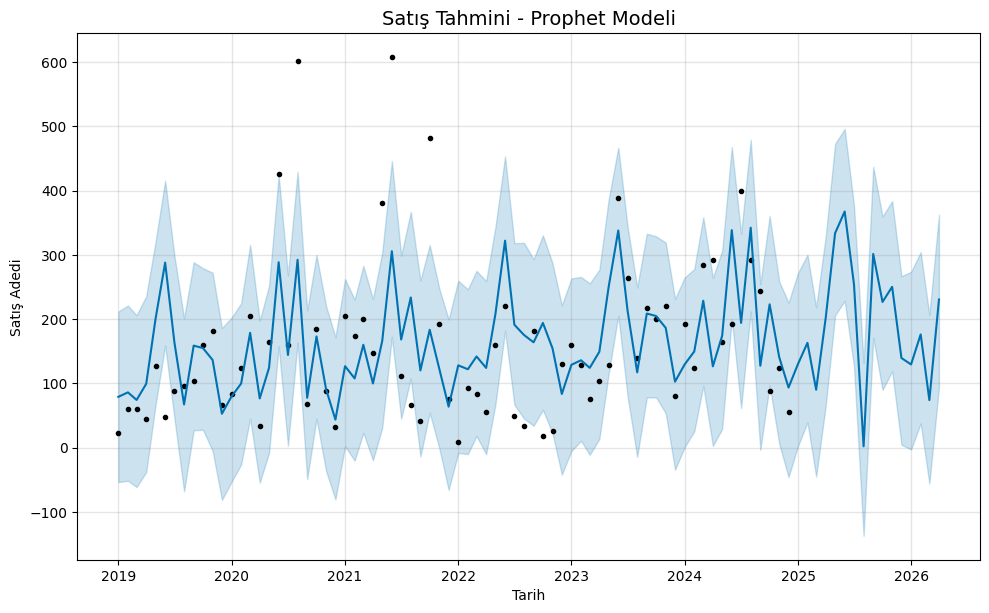

           ds        yhat  yhat_lower  yhat_upper
68 2024-09-01  127.289799   -3.815317  254.222571
69 2024-10-01  222.875896   96.798083  360.081572
70 2024-11-01  140.434844    5.516973  258.302418
71 2024-12-01   93.314787  -46.076099  225.506507
72 2024-12-31  129.479080    1.583383  271.179955
73 2025-01-31  162.915972   39.160479  300.009806
74 2025-02-28   89.972470  -45.298273  218.177058
75 2025-03-31  202.378728   65.492956  329.341468
76 2025-04-30  333.469739  205.740004  472.762371
77 2025-05-31  367.368809  228.219139  495.941414
78 2025-06-30  253.860147  125.866934  376.687371
79 2025-07-31    1.844636 -137.425905  131.726076
80 2025-08-31  301.336651  170.706096  436.975418
81 2025-09-30  226.570856   89.664344  359.639986
82 2025-10-31  250.127827  118.714259  383.634629
83 2025-11-30  139.298752    4.254510  266.708704
84 2025-12-31  129.295742   -2.971674  273.400819
85 2026-01-31  176.073380   37.380716  304.028161
86 2026-02-28   73.775015  -56.065041  206.481555


In [2]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# Veriniz (örnek: 2019-01 → 2024-12)
data = {
"2019-01":22,"2019-02":60,"2019-03":60,"2019-04":45,"2019-05":127,
"2019-06":48,"2019-07":88,"2019-08":96,"2019-09":103,"2019-10":160,
"2019-11":181,"2019-12":66,"2020-01":84,"2020-02":124,"2020-03":204,
"2020-04":33,"2020-05":164,"2020-06":425,"2020-07":160,"2020-08":601,
"2020-09":68,"2020-10":184,"2020-11":88,"2020-12":32,"2021-01":205,
"2021-02":173,"2021-03":200,"2021-04":147,"2021-05":380,"2021-06":608,
"2021-07":112,"2021-08":66,"2021-09":41,"2021-10":482,"2021-11":192,
"2021-12":75,"2022-01":9,"2022-02":93,"2022-03":84,"2022-04":55,
"2022-05":160,"2022-06":220,"2022-07":49,"2022-08":33,"2022-09":182,
"2022-10":18,"2022-11":25,"2022-12":130,"2023-01":160,"2023-02":128,
"2023-03":76,"2023-04":104,"2023-05":128,"2023-06":388,"2023-07":264,
"2023-08":139,"2023-09":217,"2023-10":200,"2023-11":220,"2023-12":80,
"2024-01":192,"2024-02":124,"2024-03":284,"2024-04":292,"2024-05":164,
"2024-06":192,"2024-07":400,"2024-08":292,"2024-09":244,"2024-10":88,
"2024-11":124,"2024-12":56
}



# DataFrame hazırlama
df = pd.DataFrame(list(data.items()), columns=["ds","y"])
df["ds"] = pd.to_datetime(df["ds"])

# Prophet modeli
model = Prophet(yearly_seasonality=True, weekly_seasonality=False)
model.fit(df)

# Gelecek 16 ay için tahmin (2025-09 → 2026-12)
future = model.make_future_dataframe(periods=16, freq="M")
forecast = model.predict(future)

# Grafik
fig1 = model.plot(forecast)
plt.title("Satış Tahmini - Prophet Modeli", fontsize=14)
plt.xlabel("Tarih")
plt.ylabel("Satış Adedi")
plt.show()

# Son 20 aylık tahmin tablosu
print(forecast[["ds","yhat","yhat_lower","yhat_upper"]].tail(20))
